# Один агент, любая задача: реализуем скиллы на LangChain с нуля

Мастер-класс Сергея Тращенкова (GigaChain / Сбер)

---

В этом ноутбуке мы пройдём полный путь от нуля до рабочего агента со скиллами:
изучим референсные скиллы Anthropic, создадим свои с помощью `skill-creator`,
а затем покажем, как тот же набор скиллов подключается к агенту на чистом LangChain v1.

**Что понадобится:** Python 3.12+, `uv`, API-ключ для выбранной модели.

## Setup — окружение

### Менеджер пакетов uv

В этом мастер-классе мы используем `uv` — современный менеджер пакетов для Python.
Он заметно быстрее `pip` и `poetry`, умеет изолировать окружения и воспроизводить
их один-в-один на любой машине. Если раньше не работали с ним — не страшно,
установка занимает одну команду.

**macOS / Linux:**
```bash
curl -LsSf https://astral.sh/uv/install.sh | sh
```

**Windows:**
```powershell
powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"
```

После установки перезапустите терминал и проверьте:
```bash
uv --version
```

Запускайте Jupyter **только через `uv run`**, иначе он не увидит зависимости проекта:
```bash
uv run jupyter notebook masterclass.ipynb
```

### Зависимости

Устанавливаем всё необходимое одной командой. Если вы запускаете ноутбук
через `uv run jupyter`, зависимости уже должны быть установлены.
Ячейка ниже — для тех, кто запускает впервые или хочет убедиться.

### Выбор модели

Агент на harness — это не чат. Ему предстоит планировать, читать файлы,
вызывать инструменты в несколько шагов и принимать решения. Поэтому
**модель имеет значение**: слабая модель будет теряться в длинных цепочках.

На мастер-классе используется **GLM-5.1 через OpenRouter**.
Вы можете подключить то, что у вас уже есть.

| Провайдер | Пакет | Переменная окружения |
|---|---|---|
| OpenRouter (платно) | `langchain-openrouter` | `OPENROUTER_API_KEY` |
| OpenRouter (free) | `langchain-openrouter` | `OPENROUTER_API_KEY` |
| Ollama Cloud | `langchain-ollama` | `OLLAMA_API_BASE` |
| OpenAI | `langchain-openai` | `OPENAI_API_KEY` |

Добавьте ключ в файл `.env` в папке проекта:
```bash
echo "OPENROUTER_API_KEY=sk-or-v1-..." >> .env
```

**Бесплатные варианты:**
- OpenRouter предоставляет ряд моделей бесплатно — ищите модели с суффиксом `:free`
  (например, `meta-llama/llama-3.3-70b-instruct:free`)
- Ollama Cloud позволяет запускать открытые модели без локального GPU

In [1]:
from dotenv import load_dotenv
load_dotenv()

# ── Выберите и раскомментируйте нужный вариант ──────────────────

# OpenRouter — используется на мастер-классе
from langchain_openrouter import ChatOpenRouter
llm = ChatOpenRouter(model="z-ai/glm-5.1")

# OpenRouter free
# llm = ChatOpenRouter(model="meta-llama/llama-3.3-70b-instruct:free")

# Ollama Cloud
# from langchain_ollama import ChatOllama
# llm = ChatOllama(model="llama3.1:8b", base_url="https://api.ollama.ai")

# OpenAI
# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model="gpt-4o")

print(f"✓ LLM: {llm.__class__.__name__}")

✓ LLM: ChatOpenRouter


### Наблюдаемость: Arize Phoenix

Мы будем смотреть на агента изнутри: какой инструмент вызвал, когда прочитал
скилл, сколько шагов потребовалось. Для этого подключим Arize Phoenix —
он запустится локально и будет собирать трейсы всех агентов в ноутбуке.

После запуска ячейки ниже откройте **http://localhost:6006** в браузере.

In [2]:
import phoenix as px
session = px.launch_app()

from openinference.instrumentation.langchain import LangChainInstrumentor
from opentelemetry import trace as otel_trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import BatchSpanProcessor
from opentelemetry.exporter.otlp.proto.http.trace_exporter import OTLPSpanExporter

# Phoenix принимает трейсы на том же порту, что и UI — 6006, путь /v1/traces
exporter = OTLPSpanExporter(endpoint="http://localhost:6006/v1/traces")

provider = TracerProvider()
provider.add_span_processor(BatchSpanProcessor(exporter))
otel_trace.set_tracer_provider(provider)
LangChainInstrumentor().instrument(tracer_provider=provider)

print(f"✓ Phoenix запущен: {session.url}")
print("  Трейсы → http://localhost:6006/v1/traces")

/Users/Sergej/.local/share/uv/python/cpython-3.12.10-macos-aarch64-none/lib/python3.12/contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_cumulative_llm_token_count_total
  next(self.gen)
/Users/Sergej/.local/share/uv/python/cpython-3.12.10-macos-aarch64-none/lib/python3.12/contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_latency
  next(self.gen)


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix
✓ Phoenix запущен: http://localhost:6006/
  Трейсы → http://localhost:6006/v1/traces


### Подготовка скиллов

#### Репозиторий Anthropic и лицензии

Anthropic выложили на GitHub репозиторий [`anthropics/skills`](https://github.com/anthropics/skills) — 17 скиллов для агентов. У них **разные лицензии**.

**Apache 2.0** — свободное использование, копирование, распространение:

| Скилл | Что делает |
|---|---|
| `skill-creator` | Создаёт и улучшает скиллы — **используем сегодня** как основной инструмент |
| `algorithmic-art` | Генеративное искусство на p5.js с интерактивными параметрами |
| `brand-guidelines` | Применяет фирменный стиль Anthropic к артефактам |
| `canvas-design` | Создаёт постеры и изображения в PNG/PDF |
| `claude-api` | Разработка и отладка кода на Claude API / Anthropic SDK |
| `doc-coauthoring` | Совместное написание документации по структурированному процессу |
| `frontend-design` | Production-grade веб-интерфейсы (React, HTML/CSS) |
| `internal-comms` | Внутренние коммуникации: отчёты, ньюслеттеры, инцидент-репорты |
| `mcp-builder` | Создание MCP-серверов на Python (FastMCP) или TypeScript |
| `slack-gif-creator` | Анимированные GIF для Slack с оптимизацией под ограничения платформы |
| `theme-factory` | 10 готовых тем оформления для слайдов, документов, артефактов |
| `web-artifacts-builder` | Сложные HTML-артефакты с React, Tailwind, shadcn/ui |
| `webapp-testing` | Тестирование веб-приложений через Playwright (скриншоты, логи, UI) |

**Source-available (© 2025 Anthropic, All rights reserved)** — исходники открыты для изучения, но копировать и распространять нельзя:

| Скилл | Что делает |
|---|---|
| `docx` | Создание и редактирование Word-документов — **изучаем сегодня** как референс |
| `xlsx` | Работа с Excel-таблицами и формулами — **изучаем сегодня** как референс |
| `pdf` | Работа с PDF: создание, слияние, разбивка, OCR, заполнение форм |
| `pptx` | Создание и редактирование презентаций PowerPoint |

Source-available — стандартная практика: компания показывает подход, но оставляет коммерческие права за собой.

#### Что мы делаем

Ячейка ниже клонирует репозиторий Anthropic **автоматически** — ничего делать вручную не нужно. Дальше:

- **`skill-creator`** — копируем в папку проекта `skills/`. Apache 2.0, всё чисто.
- **`docx` и `xlsx`** — оставляем во временной папке `/tmp`, используем только как **референс для изучения**. Агент их прочитает, поймёт подход — и напишет наши скиллы с нуля своими словами.

Именно так и покажем полный цикл: изучить чужой опыт → создать своё.

In [6]:
import subprocess, shutil
from pathlib import Path

project_root = Path.cwd().resolve()
skills_dir = project_root / "skills"
skills_dir.mkdir(exist_ok=True)

# Клонируем официальный репозиторий скиллов Anthropic
anthropic_skills = Path("/tmp/anthropics-skills")
if not anthropic_skills.exists():
    subprocess.run([
        "git", "clone", "--depth=1",
        "https://github.com/anthropics/skills",
        str(anthropic_skills)
    ], check=True)
    print("✓ Репозиторий anthropics/skills склонирован")

# Копируем skill-creator (Apache 2.0)
src = anthropic_skills / "skills" / "skill-creator"
dst = skills_dir / "skill-creator"
if not dst.exists():
    shutil.copytree(src, dst)
    print(f"✓ skill-creator скопирован в {dst}")
else:
    print("✓ skill-creator уже есть")

# Путь к reference-скиллам Anthropic (только для изучения)
anthropic_doc_skills = anthropic_skills / "skills"
print(f"\nСкиллы готовы:")
print(f"  skills/         → {skills_dir}")
print(f"  reference (ro)  → {anthropic_doc_skills}")

✓ skill-creator уже есть

Скиллы готовы:
  skills/         → /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/skills
  reference (ro)  → /tmp/anthropics-skills/skills


#### Сброс перед повторным запуском (опционально)

Если хотите пройти мастер-класс заново с чистого листа — запустите ячейку ниже.
Она удалит скиллы, созданные агентом (`docx`, `xlsx`, `bug-report`), и очистит папки `output/` и `requirements/`. `skill-creator` при этом сохранится.

In [3]:
# Запускайте только если хотите начать заново
import shutil
from pathlib import Path

project_root = Path.cwd().resolve()
skills_dir = project_root / "skills"

# Скиллы, созданные агентом в процессе мастер-класса
agent_skills = ["docx", "xlsx", "bug-report"]
for name in agent_skills:
    p = skills_dir / name
    if p.exists():
        shutil.rmtree(p)
        print(f"✓ Удалён skills/{name}/")

# Очищаем выходные папки
for folder in ["output", "requirements"]:
    p = project_root / folder
    if p.exists():
        shutil.rmtree(p)
        p.mkdir()
        print(f"✓ Очищена папка {folder}/")

print("\nГотово. skill-creator сохранён, можно запускать с начала.")

✓ Удалён skills/docx/
✓ Очищена папка output/
✓ Очищена папка requirements/

Готово. skill-creator сохранён, можно запускать с начала.


### Агент

Создаём одного агента на Deep Agents, который будет работать во всех блоках.
Он получает доступ к файловой системе и к папке со скиллами —
именно туда будут попадать все скиллы, которые мы создадим.

In [10]:
from deepagents import create_deep_agent
from deepagents.backends import LocalShellBackend
from langgraph.checkpoint.memory import MemorySaver

backend = LocalShellBackend(
    root_dir=str(project_root),
    virtual_mode=False,
    timeout=1200,
)

agent = create_deep_agent(
    model=llm,
    backend=backend,
    skills=[str(skills_dir)],
    checkpointer=MemorySaver(),
    system_prompt=(
        f"Рабочая папка проекта: {project_root}. "
        "Используй реальные абсолютные пути внутри неё. "
        "При создании скиллов пиши инструкции своими словами — "
        "не копируй текст из референсных материалов."
    ),
)

print("✓ Агент создан")
print(f"  Скиллы: {skills_dir}")
print(f"  Рабочая папка: {project_root}")

✓ Агент создан
  Скиллы: /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/skills
  Рабочая папка: /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass


---
## Блок 1 — Создаём скилл для Word-документов

Anthropic выложили на GitHub референсные скиллы для работы с документами.
Их лицензия запрещает прямое копирование и распространение — но мы можем
изучить их как публичный референс, понять подход и написать свой скилл с нуля.

Именно это мы и сделаем: попросим агента прочитать референс, выделить
ключевую функциональность — и создать собственный `docx`-скилл,
не нарушая чужую лицензию.

In [7]:
config = {"configurable": {"thread_id": "docx-skill"}}

res = agent.invoke(
    {"messages": [{
        "role": "user",
        "content": (
            f"Изучи референсный скилл Anthropic для работы с docx-файлами: "
            f"{anthropic_doc_skills}/docx/. "
            "Прочитай SKILL.md и скрипты. "
            "Выпиши основную функциональность: что умеет этот скилл, "
            "какие форматы поддерживает, какие ограничения есть. "
            "Не копируй текст — пиши своими словами."
        )
    }]},
    config=config,
)

for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Изучи референсный скилл Anthropic для работы с docx-файлами: /tmp/anthropics-skills/skills/docx/. Прочитай SKILL.md и скрипты. Выпиши основную функциональность: что умеет этот скилл, какие форматы поддерживает, какие ограничения есть. Не копируй текст — пиши своими словами.
================================== Ai Message ==================================
Tool Calls:
  ls (call_5796e7fca4584afb8c30bf0b)
 Call ID: call_5796e7fca4584afb8c30bf0b
  Args:
    path: /tmp/anthropics-skills/skills/docx
================================= Tool Message =================================
Name: ls

['/tmp/anthropics-skills/skills/docx/LICENSE.txt', '/tmp/anthropics-skills/skills/docx/SKILL.md', '/tmp/anthropics-skills/skills/docx/scripts/']
================================== Ai Message ==================================
Tool Calls:
  read_file (call_8305ad5b784b4dd4a72d844e)
 Call ID: call_8305ad5b784b4dd4a72d844e
  Args:

In [8]:
res = agent.invoke(
    {"messages": [{
        "role": "user",
        "content": (
            f"Теперь создай наш собственный скилл для работы с docx в папке {skills_dir}/docx/. "
            "Возьми из референса идею и подход, но напиши SKILL.md и скрипты полностью "
            "своими словами — не копируй ни строчки из оригинала. "
            "Скилл должен уметь: создавать документ с заголовком, параграфами и таблицей. "
            "Используй python-docx."
        )
    }]},
    config=config,
)

for msg in res["messages"]:
    msg.pretty_print()

I0000 00:00:1776596225.456855 269463099 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


================================ Human Message =================================

Изучи референсный скилл Anthropic для работы с docx-файлами: /tmp/anthropics-skills/skills/docx/. Прочитай SKILL.md и скрипты. Выпиши основную функциональность: что умеет этот скилл, какие форматы поддерживает, какие ограничения есть. Не копируй текст — пиши своими словами.
================================== Ai Message ==================================
Tool Calls:
  ls (call_5796e7fca4584afb8c30bf0b)
 Call ID: call_5796e7fca4584afb8c30bf0b
  Args:
    path: /tmp/anthropics-skills/skills/docx
================================= Tool Message =================================
Name: ls

['/tmp/anthropics-skills/skills/docx/LICENSE.txt', '/tmp/anthropics-skills/skills/docx/SKILL.md', '/tmp/anthropics-skills/skills/docx/scripts/']
================================== Ai Message ==================================
Tool Calls:
  read_file (call_8305ad5b784b4dd4a72d844e)
 Call ID: call_8305ad5b784b4dd4a72d844e
  Args:

### Проверяем новый скилл

Скилл создан. Теперь запустим нового агента в новом треде и попросим
создать документ — агент должен сам найти и применить наш новый `docx`-скилл.

In [11]:
config_demo = {"configurable": {"thread_id": "docx-demo1"}}

res = agent.invoke(
    {"messages": [{
        "role": "user",
        "content": (
            f"Создай Word-документ {project_root}/output/intro.docx. "
            "двумя абзацами произвольного текста на русском языке "
            "и таблицей 3×2 с заголовками 'Параметр' и 'Значение', "
            "заполни тремя строками с выдуманными данными."
        )
    }]},
    config=config_demo,
)

for msg in res["messages"]:
    msg.pretty_print()

I0000 00:00:1776599411.316724 270074775 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599424.455362 270076907 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599429.875156 270077875 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599434.079509 270078783 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599452.847121 270082471 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599461.792526 270084294 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599467.415064 270085318 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599492.075165 270090384 fork_posix.cc:71] Other threads are currently call

================================ Human Message =================================

Создай Word-документ /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/output/intro.docx. двумя абзацами произвольного текста на русском языке и таблицей 3×2 с заголовками 'Параметр' и 'Значение', заполни тремя строками с выдуманными данными.
================================== Ai Message ==================================
Tool Calls:
  read_file (call_b28c877e5e9648f5be1e42fd)
 Call ID: call_b28c877e5e9648f5be1e42fd
  Args:
    file_path: /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/skills/docx/SKILL.md
================================= Tool Message =================================
Name: read_file

     1	---
     2	name: docx
     3	description: "Используй этот скилл, когда пользователь хочет создать, прочитать или отредактировать документ Word (.docx). Применяй его при упоминании 'Word', 'docx', 'документ', 'отчёт', 'меморандум', 'письмо', 'шаблон', а также когда нужно сгенер

---
## Блок 2 — Создаём скилл для Excel-таблиц

Повторяем тот же процесс для `xlsx`. Но добавим одно требование:
таблица должна содержать формулу, которая реально считается.
Это хороший тест — агент должен не просто создать файл,
но и убедиться, что формула работает.

In [12]:
config2 = {"configurable": {"thread_id": "xlsx-skill"}}

res = agent.invoke(
    {"messages": [{
        "role": "user",
        "content": (
            f"Изучи референсный скилл Anthropic для работы с xlsx-файлами: "
            f"{anthropic_doc_skills}/xlsx/. "
            "Прочитай SKILL.md и скрипты. "
            "Выпиши основную функциональность своими словами."
        )
    }]},
    config=config2,
)

for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Изучи референсный скилл Anthropic для работы с xlsx-файлами: /tmp/anthropics-skills/skills/xlsx/. Прочитай SKILL.md и скрипты. Выпиши основную функциональность своими словами.
================================== Ai Message ==================================
Tool Calls:
  ls (call_fe5bfbe2703649be91519066)
 Call ID: call_fe5bfbe2703649be91519066
  Args:
    path: /tmp/anthropics-skills/skills/xlsx
================================= Tool Message =================================
Name: ls

['/tmp/anthropics-skills/skills/xlsx/LICENSE.txt', '/tmp/anthropics-skills/skills/xlsx/SKILL.md', '/tmp/anthropics-skills/skills/xlsx/scripts/']
================================== Ai Message ==================================
Tool Calls:
  ls (call_cef289bf37de4dcbbb3ee50a)
 Call ID: call_cef289bf37de4dcbbb3ee50a
  Args:
    path: /tmp/anthropics-skills/skills/xlsx/scripts
  read_file (call_dbbd269dfb6540c5af7ba446)
 Call ID

In [13]:
res = agent.invoke(
    {"messages": [{
        "role": "user",
        "content": (
            f"Создай наш собственный скилл для xlsx в папке {skills_dir}/xlsx/. "
            "Пиши SKILL.md и скрипты своими словами, не копируя оригинал. "
            "Требование: скилл должен уметь создавать таблицу с данными и формулами Excel "
            "(SUM, AVERAGE). Используй openpyxl. "
            "После создания скилла — сразу проверь его: создай тестовую таблицу "
            f"с числами в столбце A и формулой SUM в последней строке, сохрани в {project_root}/output/test.xlsx."
        )
    }]},
    config=config2,
)

for msg in res["messages"]:
    msg.pretty_print()

I0000 00:00:1776599720.466294 270134485 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599832.980955 270155494 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599835.176050 270156457 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599837.754853 270157241 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599840.257706 270157517 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599842.512314 270158263 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599847.338336 270159208 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776599849.920807 270159561 fork_posix.cc:71] Other threads are currently call

================================ Human Message =================================

Изучи референсный скилл Anthropic для работы с xlsx-файлами: /tmp/anthropics-skills/skills/xlsx/. Прочитай SKILL.md и скрипты. Выпиши основную функциональность своими словами.
================================== Ai Message ==================================
Tool Calls:
  ls (call_fe5bfbe2703649be91519066)
 Call ID: call_fe5bfbe2703649be91519066
  Args:
    path: /tmp/anthropics-skills/skills/xlsx
================================= Tool Message =================================
Name: ls

['/tmp/anthropics-skills/skills/xlsx/LICENSE.txt', '/tmp/anthropics-skills/skills/xlsx/SKILL.md', '/tmp/anthropics-skills/skills/xlsx/scripts/']
================================== Ai Message ==================================
Tool Calls:
  ls (call_cef289bf37de4dcbbb3ee50a)
 Call ID: call_cef289bf37de4dcbbb3ee50a
  Args:
    path: /tmp/anthropics-skills/skills/xlsx/scripts
  read_file (call_dbbd269dfb6540c5af7ba446)
 Call ID

---
## Блок 3 — LangChain v1: тот же скилл, другой агент

Deep Agents построен поверх LangChain — он добавляет готовый harness:
файловые инструменты, планирование, память, выполнение команд.
`create_agent()` из LangChain v1 — это чистый ReAct-loop без всего этого.

Сценарий: у нас уже есть скиллы из блоков 1 и 2. Теперь подключим их
к агенту на голом LangChain — и посмотрим, что приходится добавлять вручную,
чтобы получить тот же результат.

Сначала Deep Agents создаст документ с требованиями к баг-репортам —
он станет входными данными для LangChain-агента.

In [14]:
# Создаём документ с требованиями к баг-репортам
config3 = {"configurable": {"thread_id": "bug-requirements"}}

res = agent.invoke(
    {"messages": [{
        "role": "user",
        "content": (
            f"Создай Word-документ {project_root}/requirements/bug_report_requirements.docx. "
            "Документ описывает требования к оформлению баг-репортов в нашей команде. "
            "Включи: обязательные поля (заголовок, severity, описание, шаги воспроизведения, "
            "ожидаемый и фактический результат, окружение), "
            "правила приоритизации severity (critical/high/medium/low), "
            "пример хорошего и плохого баг-репорта."
        )
    }]},
    config=config3,
)

for msg in res["messages"]:
    msg.pretty_print()

I0000 00:00:1776600717.149658 270326115 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776600743.892045 270330447 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776600744.671883 270331207 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776600745.490018 270331345 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776600748.151760 270332121 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776600781.228298 270338401 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776600783.607468 270338896 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776600786.167988 270339358 fork_posix.cc:71] Other threads are currently call

================================ Human Message =================================

Создай Word-документ /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/requirements/bug_report_requirements.docx. Документ описывает требования к оформлению баг-репортов в нашей команде. Включи: обязательные поля (заголовок, severity, описание, шаги воспроизведения, ожидаемый и фактический результат, окружение), правила приоритизации severity (critical/high/medium/low), пример хорошего и плохого баг-репорта.
================================== Ai Message ==================================
Tool Calls:
  read_file (call_1fbcc11d4c684c3483b91404)
 Call ID: call_1fbcc11d4c684c3483b91404
  Args:
    file_path: /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/skills/docx/SKILL.md
================================= Tool Message =================================
Name: read_file

     1	---
     2	name: docx
     3	description: "Используй этот скилл, когда пользователь хочет создать, прочитать

### Агент на LangChain v1

`create_agent()` даёт ReAct-loop: модель → инструменты → наблюдение → повтор.
Всё остальное — инструменты, память, middleware — добавляем сами.

Наш LangChain-агент получит те же скиллы из папки `skills/` и те же задачи,
что и Deep Agents. Разница — в том, что именно нам пришлось прописать явно.

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ToolRetryMiddleware
from langchain_core.messages import SystemMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from pathlib import Path
import os, subprocess, yaml


# --- Middleware: динамический индекс скиллов ---

class SkillsIndexMiddleware(AgentMiddleware):
    """Перед каждым вызовом модели инжектирует актуальный индекс скиллов в system message.

    Читает папку skills_dir, собирает name и description из frontmatter SKILL.md.
    Это то, что Deep Agents делает из коробки через SkillsMiddleware.
    """

    tools = []

    def __init__(self, skills_dir: Path):
        self.skills_dir = skills_dir

    def _build_index(self) -> str:
        lines = []
        for skill_dir in sorted(self.skills_dir.iterdir()):
            skill_md = skill_dir / "SKILL.md"
            if not skill_md.exists():
                continue
            text = skill_md.read_text(encoding="utf-8")
            if text.startswith("---"):
                fm = text.split("---")[1]
                meta = yaml.safe_load(fm)
                name = meta.get("name", skill_dir.name)
                desc = meta.get("description", "")
                lines.append(f"- {name}: {desc}")
        return "\n".join(lines)

    def wrap_model_call(self, request: ModelRequest, handler):
        index = self._build_index()
        injection = f"\n\nДоступные скиллы:\n{index}"

        current = request.system_message
        if current is not None:
            new_system = SystemMessage(content=current.content + injection)
        else:
            new_system = SystemMessage(content=injection.strip())

        return handler(request.override(system_message=new_system))


# --- Инструменты ---

@tool
def read_file(path: str) -> str:
    """Читает содержимое файла по пути. Поддерживает .docx и текстовые файлы.
    Внимание: для .docx читает только параграфы, таблицы теряются."""
    if path.endswith(".docx"):
        from docx import Document
        doc = Document(path)
        return "\n".join(p.text for p in doc.paragraphs if p.text.strip())
    with open(path, encoding="utf-8") as f:
        return f.read()

@tool
def read_skill(name: str) -> str:
    """Читает полный SKILL.md скилла по имени. Используй перед выполнением задачи."""
    skill_md = skills_dir / name / "SKILL.md"
    if not skill_md.exists():
        return f"Скилл '{name}' не найден в {skills_dir}."
    return skill_md.read_text(encoding="utf-8")

@tool
def write_file(path: str, content: str) -> str:
    """Записывает content в файл по пути. Создаёт папки если нужно."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)
    return f"Файл записан: {path}"

@tool
def execute(command: str) -> str:
    """Выполняет команду в shell. Возвращает stdout и stderr."""
    r = subprocess.run(command, shell=True, capture_output=True, text=True, timeout=120)
    output = r.stdout
    if r.stderr:
        output += "\n[stderr]\n" + r.stderr
    if r.returncode != 0:
        output += f"\n[exit code: {r.returncode}]"
    return output or "(нет вывода)"


# --- Агент ---

lc_agent = create_agent(
    model=llm,
    tools=[read_file, read_skill, write_file, execute],
    checkpointer=MemorySaver(),
    middleware=[
        SkillsIndexMiddleware(skills_dir),
        ToolRetryMiddleware(on_failure="continue"),
    ],
    system_prompt=f"Рабочая папка: {project_root}.",
)

print("✓ LangChain-агент создан")
print(f"  Инструменты: read_file, read_skill, write_file, execute")
print(f"  Middleware: SkillsIndexMiddleware, ToolRetryMiddleware")


✓ LangChain-агент создан
  Инструменты: read_file, read_skill, write_file, execute
  Middleware: SkillsIndexMiddleware, ToolRetryMiddleware


In [16]:
config_lc = {"configurable": {"thread_id": "lc-bug-report"}}

res = lc_agent.invoke(
    {"messages": [{
        "role": "user",
        "content": (
            f"Прочитай документ с требованиями: "
            f"{project_root}/requirements/bug_report_requirements.docx. "
            f"Затем с помощью skill-creator создай скилл bug-report в папке {skills_dir}/bug-report/. "
            "Скилл должен помогать агенту оформлять баг-репорты строго по нашим требованиям."
        )
    }]},
    config=config_lc,
)

for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Прочитай документ с требованиями: /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/requirements/bug_report_requirements.docx. Затем с помощью skill-creator создай скилл bug-report в папке /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/skills/bug-report/. Скилл должен помогать агенту оформлять баг-репорты строго по нашим требованиям.
================================== Ai Message ==================================
Tool Calls:
  read_file (call_0c28535d5ace4211b00beced)
 Call ID: call_0c28535d5ace4211b00beced
  Args:
    path: /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/requirements/bug_report_requirements.docx
  read_file (call_05e8a0c1117f4f068c085a16)
 Call ID: call_05e8a0c1117f4f068c085a16
  Args:
    path: /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/skills/skill-creator/SKILL.md
================================= Tool Message ===================

### Проверяем скилл на реальном баге

Скилл создан. Теперь даём агенту описание бага в произвольной форме
и смотрим, оформит ли он его по нашим требованиям.

In [19]:
config_lc_test = {"configurable": {"thread_id": "lc-bug-test1"}}

res = lc_agent.invoke(
    {"messages": [{
        "role": "user",
        "content": (
            "Оформи баг-репорт по описанию:\n\n"
            "при логине через google иногда редиректит на 404, "
            "бывает не всегда, примерно раз в 10, "
            "на проде замечено вчера вечером, "
            "в дев-окружении не воспроизводится.\n\n"
            f"Сохрани результат в {project_root}/output/bug_report.docx"
        )
    }]},
    config=config_lc_test,
)

for msg in res["messages"]:
    msg.pretty_print()

I0000 00:00:1776603447.380399 270851288 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776603487.039943 270858931 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776603535.951805 270868162 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


================================ Human Message =================================

Оформи баг-репорт по описанию:

при логине через google иногда редиректит на 404, бывает не всегда, примерно раз в 10, на проде замечено вчера вечером, в дев-окружении не воспроизводится.

Сохрани результат в /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/output/bug_report.docx
================================== Ai Message ==================================
Tool Calls:
  read_file (call_a36f0e2a0b474910bf8d518c)
 Call ID: call_a36f0e2a0b474910bf8d518c
  Args:
    path: /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/skills/bug-report/SKILL.md
  read_file (call_82f166e711fb49feb9d65e2f)
 Call ID: call_82f166e711fb49feb9d65e2f
  Args:
    path: /Users/Sergej/claude_code/skills_lc/agent-skills-masterclass/skills/docx/SKILL.md
================================= Tool Message =================================
Name: read_file

---
name: bug-report
description: "Помогает агенту оформлять

---

## Выводы

### Три вещи, которые важно вынести

**Скилл — это направление, а не гарантия.**  
Агент не обязан следовать инструкции буквально. Он может пропустить шаг, переформулировать его или выбрать другой путь. Скилл задаёт маршрут, но не заменяет тесты и наблюдаемость.

**Скилл работает только внутри харнесса.**  
Без `execute`, без изолированной файловой системы, без правильного набора инструментов — скилл тихо деградирует. Мы видели это в блоке 3: агент на LangChain читал SKILL.md, но не мог выполнить скрипты. Скилл — это не автономный компонент, а специализация поверх готовой инфраструктуры.

**Мы живём в эпоху универсальных агентов.**  
Не нужно держать зоопарк специализированных агентов под каждую задачу. Скилл — это способ добавить специализацию в универсального агента по запросу. Один агент, правильный харнесс, библиотека скиллов — и вы покрываете широкий спектр задач без оркестрационного ада.

### Материалы

1. [Don't Build Agents, Build Skills Instead — Anthropic (AI Engineer)](https://www.youtube.com/@AIEngineer) — концепция «гениального дилетанта», переход от специализированных агентов к библиотеке скиллов.
2. [Equipping agents for the real world with Agent Skills — Anthropic](https://www.anthropic.com/news/agent-skills) — официальный анонс открытого стандарта Agent Skills, принцип прогрессивного раскрытия.
3. [Evaluating Skills — LangChain Blog](https://blog.langchain.dev/evaluating-skills/) — методология тестирования скиллов: метрики, Docker-среды, LangSmith.
4. [LangChain Skills — LangChain Blog](https://blog.langchain.dev/langchain-skills/) — набор из 11 открытых скиллов, прирост с 25% до 95% на задачах Claude Code.
5. [Agent Skills Overview — agentskills.io](https://agentskills.io/) — обзор открытого стандарта.
6. [Skills — Deep Agents Docs](https://docs.langchain.com/oss/python/deepagents/skills) — техническое руководство: Skills vs. Memory, процесс Match → Read → Execute в Deep Agents.
7. [Agent Skills Specification — agentskills.io](https://agentskills.io/specification) — детальная спецификация формата: структура папок, поля YAML-frontmatter, ограничения.
8. [Your harness, your memory — Harrison Chase](https://blog.langchain.dev/your-harness-your-memory/) — о важности harness engineering и рисках закрытых платформ.
9. [langchain-ai/langchain-skills — GitHub](https://github.com/langchain-ai/langchain-skills) — репозиторий готовых скиллов для LangChain, LangGraph и Deep Agents.
10. [ai-forever/gigachain — GitHub](https://github.com/ai-forever/gigachain) — репозиторий команды GigaChain.
11. [Канал Сергея Тращенков](https://t.me/gigatrash) 

---

### Оцените мастерклас

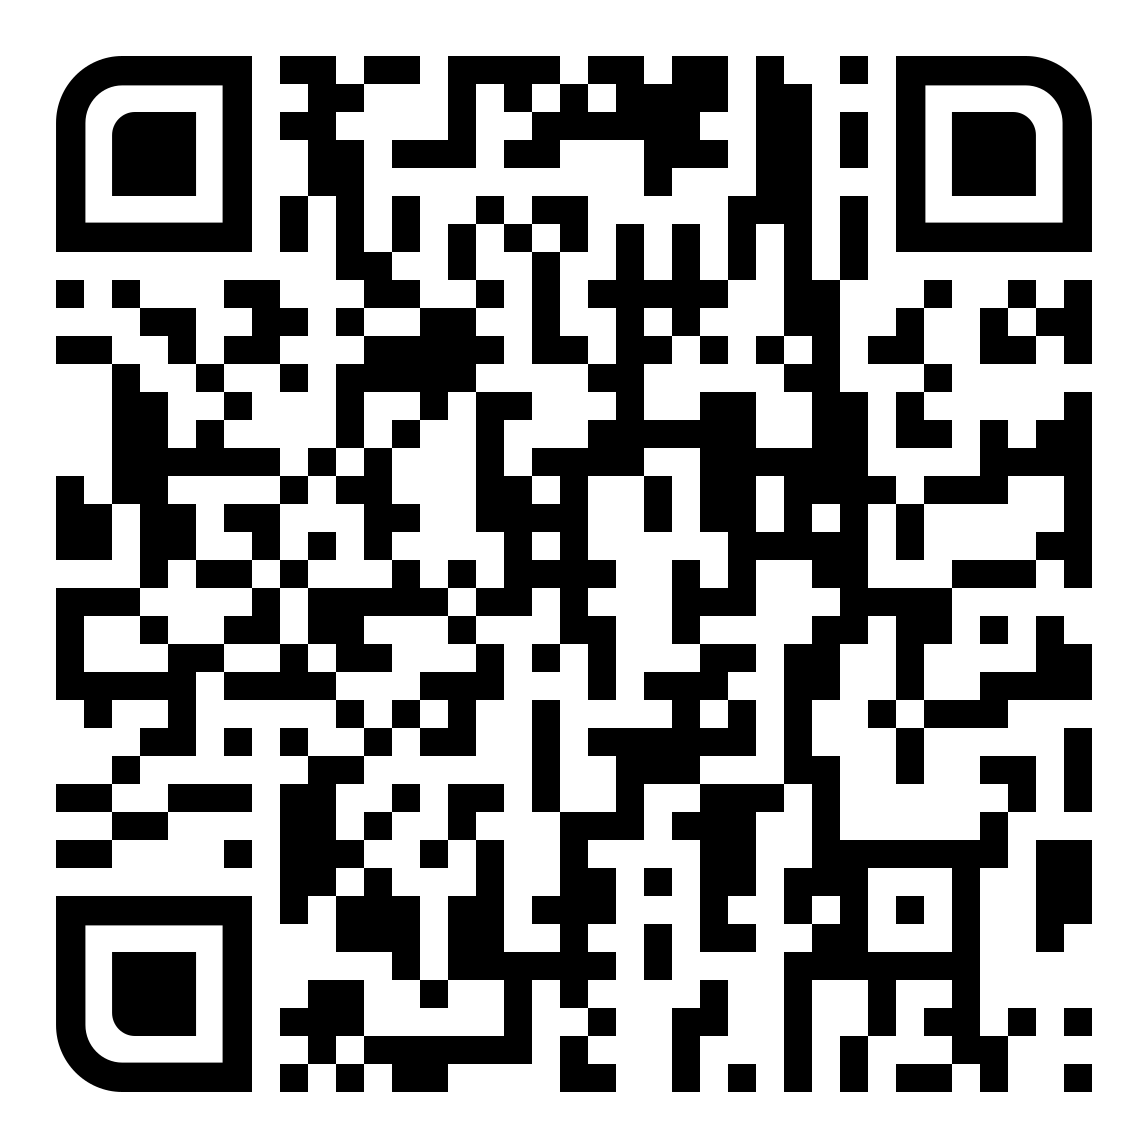